## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted — *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work — responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity — not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work — or AI-generated work — as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance — it is professional formation.***

### TL;DR

Use AI; Don’t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you can’t explain it, you probably shouldn’t submit it.***

---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



In [3]:
# Standard imports and aliases.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.v2 as T     # Use transforms v2; much more efficient.
from torchvision.datasets import GTSRB

# pick CPU/GPU device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    gpu_name = torch.cuda.get_device_name(device.index if device.index is not None else 0)
    print(f"Using device: {device} (GPU: {gpu_name})")
else:
    print("Using device: cpu (CPU)")

# Your code here.
tranform = T.Compose([T.ToTensor()])
ds_train = GTSRB(root='data', split='train', transform=tranform, download=True)
ds_test = GTSRB(root='data', split='test', transform=tranform, download=True)

Using device: cuda (GPU: AMD Radeon RX 6700 XT)


/home/eros/DLA_Projects/.venv/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [4]:
ds_train[0][0].shape

torch.Size([3, 30, 29])

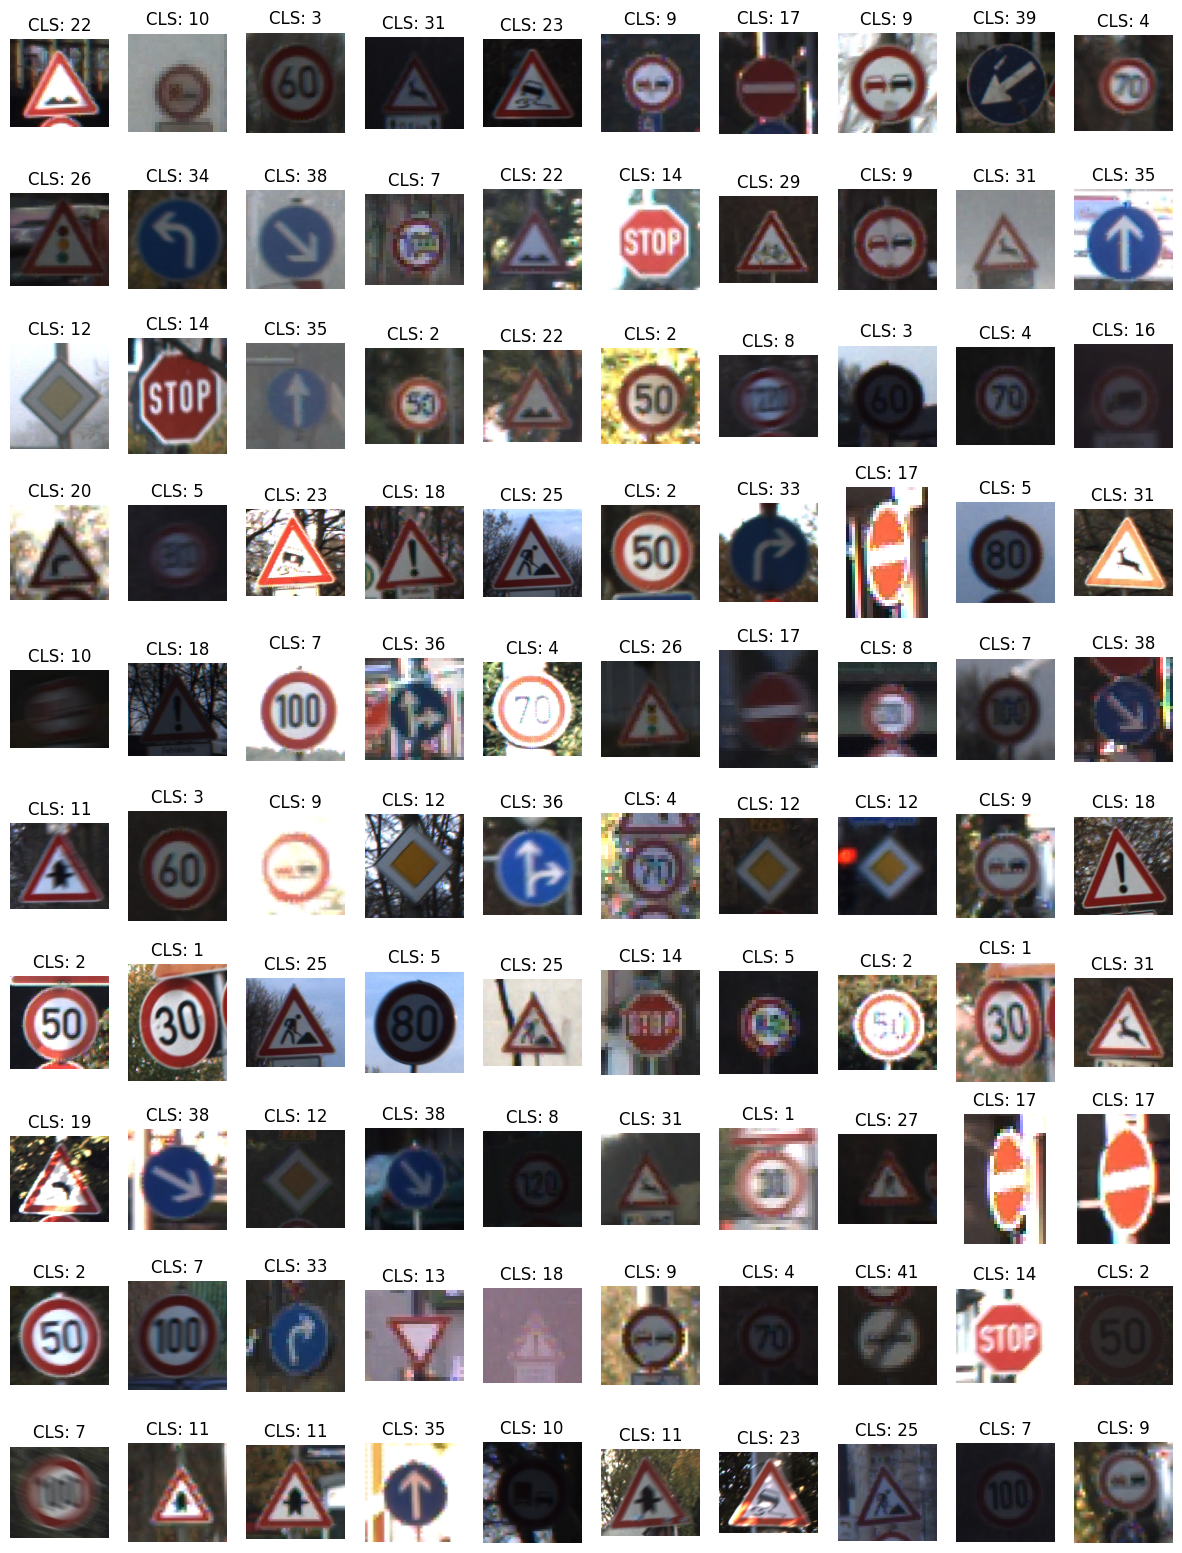

In [5]:
num_samples = 100
image_samples = [ds_train[idx] for idx in np.random.choice(len(ds_train), num_samples)] # Select 100 random samples from the training dataset.

# Visualize the selected samples.
plt.figure(figsize=(15, 20))
for (idx, (im, cls)) in enumerate(image_samples):
    plt.subplot(10, 10, idx + 1)
    plt.imshow(im.permute(1, 2, 0)) # Permute the image tensor to (H, W, C) for plotting.
    plt.title(f'CLS: {cls}')
    plt.axis('off')

In [6]:
# Compute the aspect ratio (AR) of each image in the training dataset and store it in a DataFrame (collect metadata statistics in a Pandas dataframe)
import pandas as pd
df_stats = pd.DataFrame([(cls, im.shape[1], im.shape[2]) for (im, cls) in ds_train], columns=['CLS', 'HEIGHT', 'WIDTH'])
df_stats['AR'] = df_stats['WIDTH'] / df_stats['HEIGHT'] # aspect ratio

In [7]:
# Display the statistics of the collected metadata.
df_stats.describe()

,CLS,HEIGHT,WIDTH,AR
count,26640.000000,26640.000000,26640.000000,26640.000000
mean,15.887387,50.365128,50.933784,1.008718
std,12.044099,23.161523,24.373418,0.072100
min,0.000000,25.000000,25.000000,0.368132
25%,5.000000,35.000000,35.000000,0.972222
50%,12.000000,43.000000,43.000000,1.000000
75%,25.000000,58.000000,58.000000,1.044444
max,42.000000,225.000000,243.000000,1.417808


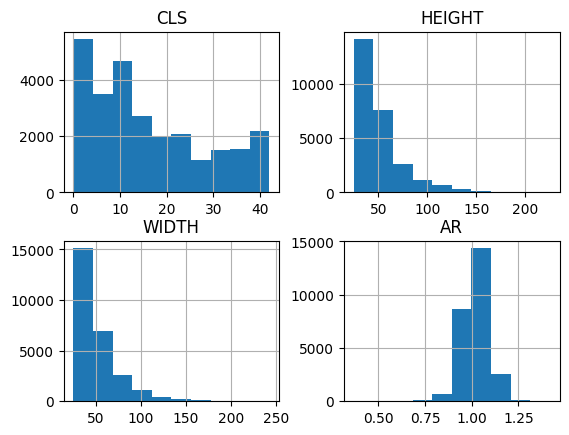

In [8]:
# Visualize the distribution of the collected metadata.
_ = df_stats.hist()

In [9]:
# Define the final transform pipeline for training and test images:
#   - Resize: scale the shorter side to 70 pixels to standardize small images.
#   - RandomCrop: randomly crop a 64x64 patch, acting as a data augmentation step.
#   - ToTensor: convert the PIL image to a float tensor in [0, 1].
#   - Normalize: subtract the ResNet channel means and divide by std deviations,
#     so the input distribution matches what the pretrained backbone expects.
# The same transform is applied to both splits; RandomCrop introduces
# stochasticity only at training time (no separate deterministic crop is used here).
transform = T.Compose([T.Resize(70), T.RandomCrop((64, 64)), T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
ds_train = GTSRB(root='data', split='train', transform=transform, download=True)
ds_test = GTSRB(root='data', split='test', transform=transform, download=True)


/home/eros/DLA_Projects/.venv/lib/python3.10/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..1.6465361].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7906162..-0.7238344].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6041614..1.3153814].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.2391288].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.843908..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637812..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3986644..-0.6541

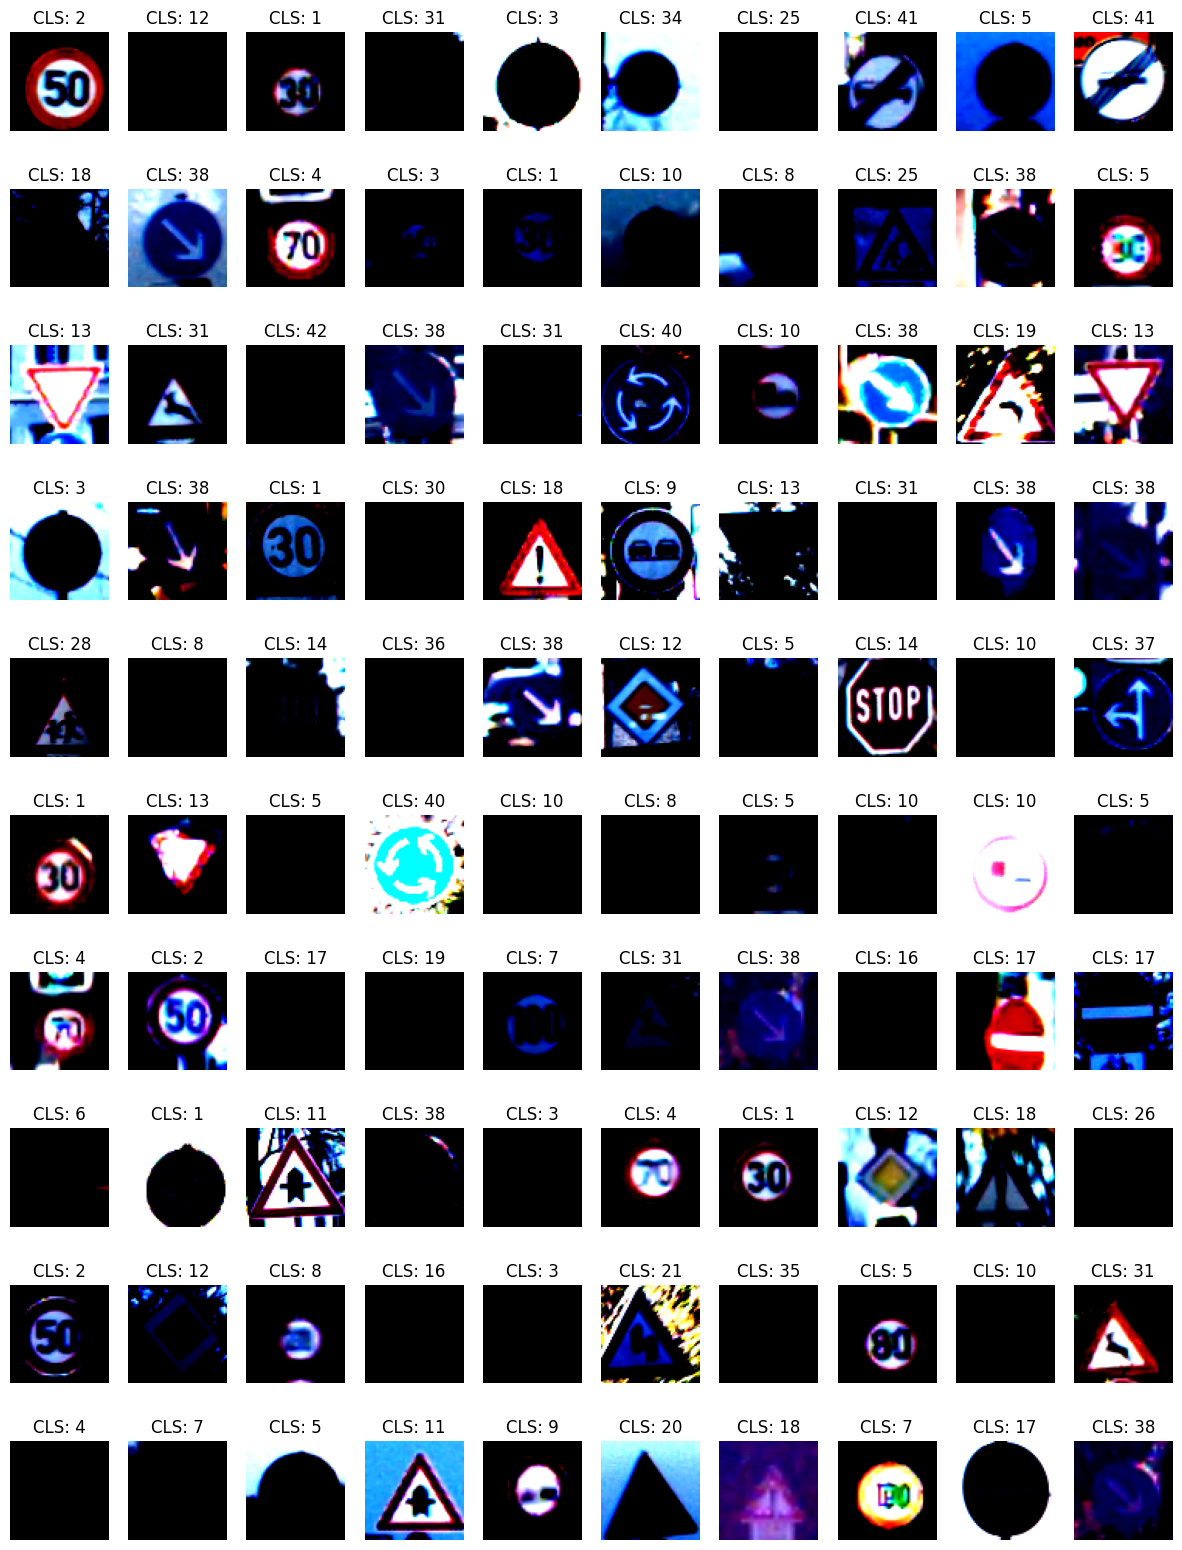

In [10]:
num_samples = 100
image_samples = [ds_train[idx] for idx in np.random.choice(len(ds_train), num_samples)] # Select 100 random samples from the training dataset.

# Visualize the selected samples.
plt.figure(figsize=(15, 20))
for (idx, (im, cls)) in enumerate(image_samples):
    plt.subplot(10, 10, idx + 1)
    plt.imshow(im.permute(1, 2, 0)) # Permute the image tensor to (H, W, C) for plotting.
    plt.title(f'CLS: {cls}')
    plt.axis('off')
    
# The images are now resized to 64x64 and normalized, so they may look different from the original ones. The errors are due to the normalization.

### Analysis

Deep Learning is very much an *experimental* discipline. Experiments are *nothing* without analysis and interpretation. Be sure to **always** stop and analyze the results of preliminary explorations. Note anything significant and -- importantly -- anything that is going to be relevant for what comes next.

So... In this Markdown cell you should collect and report (using, for the love of God, the *rich markup capabilities of Markdown*) any relevant findings you have made before proceding.

**Important Warning**: This is the **one and only** time I will remind you of the need to provide *analysis* and interpretation of your experimental methodology and results. The responsibility is *yours* to include it elsewhere.


---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

In [11]:
from torchvision.models import list_models, get_model

In [12]:
list_models()

['alexnet',
 'convnext_base',
 'convnext_large',
 'convnext_small',
 'convnext_tiny',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'efficientnet_b0',
 'efficientnet_b1',
 'efficientnet_b2',
 'efficientnet_b3',
 'efficientnet_b4',
 'efficientnet_b5',
 'efficientnet_b6',
 'efficientnet_b7',
 'efficientnet_v2_l',
 'efficientnet_v2_m',
 'efficientnet_v2_s',
 'fasterrcnn_mobilenet_v3_large_320_fpn',
 'fasterrcnn_mobilenet_v3_large_fpn',
 'fasterrcnn_resnet50_fpn',
 'fasterrcnn_resnet50_fpn_v2',
 'fcn_resnet101',
 'fcn_resnet50',
 'fcos_resnet50_fpn',
 'googlenet',
 'inception_v3',
 'keypointrcnn_resnet50_fpn',
 'lraspp_mobilenet_v3_large',
 'maskrcnn_resnet50_fpn',
 'maskrcnn_resnet50_fpn_v2',
 'maxvit_t',
 'mc3_18',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'mvit_v1_b',
 'mvit_v2_s',
 'quantized_googlenet',
 '

In [13]:
from torch.utils.data import DataLoader
import torch.nn as nn

# The training dataloader
batch_size = 1024
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=True)

# load our ResNet model
model = get_model('resnet18', weights='DEFAULT')
model.fc = nn.Identity() # Remove the final fully connected layer to get feature embeddings instead of class predictions.
model = model.to(device)

In [14]:
from tqdm.notebook import tqdm

# Extract features for all training images using the pretrained ResNet backbone.
# We store the output features and their corresponding classes in separate lists, which are then concatenated into tensors for further analysis.
# We use torch.no_grad() to disable gradient computation since we are only extracting features and not training the model.
# The model is set to evaluation mode with model.eval() to ensure that layers like dropout and batch normalization behave appropriately during feature extraction.
train_feats = []
train_classes = []
model.eval()
for (ims, cls) in tqdm(dl_train):
    ims = ims.to(device)
    with torch.no_grad():
        train_feats.append(model(ims))
    train_classes.append(cls)
train_feats = torch.vstack(train_feats).cpu()
train_classes = torch.concat(train_classes)

  0%|          | 0/27 [00:00<?, ?it/s]

In [15]:
# Display the shape of the extracted features tensor to verify that we have the expected number of samples and feature dimensions.
train_feats.shape

torch.Size([26640, 512])

In [16]:
test_feats = []
test_classes = []
model.eval()
for (ims, cls) in tqdm(dl_test):
    ims = ims.to(device)
    with torch.no_grad():
        test_feats.append(model(ims))
    test_classes.append(cls)
test_feats = torch.vstack(test_feats).cpu()
test_classes = torch.concat(test_classes)

  0%|          | 0/13 [00:00<?, ?it/s]

In [17]:
test_feats.shape


torch.Size([12630, 512])

In [18]:
# A reproducible baseline
from sklearn.svm import SVC

svc = SVC(kernel='linear')
svc.fit(train_feats, train_classes)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [19]:
from sklearn.metrics import classification_report

print(classification_report(svc.predict(test_feats), test_classes))

              precision    recall  f1-score   support

           0       0.28      0.24      0.26        70
           1       0.64      0.49      0.56       943
           2       0.47      0.44      0.45       810
           3       0.35      0.34      0.35       466
           4       0.54      0.59      0.56       601
           5       0.47      0.50      0.48       589
           6       0.89      0.95      0.92       140
           7       0.54      0.56      0.55       431
           8       0.36      0.47      0.41       346
           9       0.78      0.88      0.83       424
          10       0.88      0.83      0.85       693
          11       0.64      0.48      0.54       562
          12       0.98      0.93      0.95       726
          13       0.99      0.96      0.97       745
          14       0.81      0.91      0.86       241
          15       0.96      0.97      0.96       209
          16       0.79      0.91      0.85       129
          17       0.84    

### Analysis — Exercise 1.2: A Stable and Reproducible Baseline

#### Approach

The goal of this exercise was to establish a **training-free classification baseline** by reusing a pretrained CNN as a fixed feature extractor and plugging a classical classifier on top of the extracted representations.

**Feature extractor — ResNet-18 (ImageNet pretrained)**

We loaded `resnet18` with `weights='DEFAULT'` from `torchvision`. The final fully-connected layer (`model.fc`) was replaced with `nn.Identity()`, turning the network into a pure feature extractor that outputs a **512-dimensional** embedding vector for each input image. No weights were updated at any point; the backbone was used entirely frozen (`model.eval()` + `torch.no_grad()`).

**Feature extraction**

Features were extracted batch-by-batch (batch size = 1024) using a `DataLoader`. All partial outputs were collected in a list and concatenated into a single tensor at the end with `torch.vstack`. This procedure was applied to both the training and test splits.

**Classifier — Linear SVM**

The extracted 512-d feature vectors were used to train a **linear Support Vector Machine** (`SVC(kernel='linear')` from scikit-learn). The classifier was fit on the training-set features and evaluated on the test-set features using `classification_report`, which reports per-class precision, recall, and F1-score, plus macro/weighted averages across all 43 GTSRB classes.

---

#### Key observations

- Even with a completely frozen backbone and a simple linear classifier, pretrained ImageNet features provide a strong starting point for traffic sign classification — demonstrating the power of transfer learning even without any domain-specific fine-tuning.
- The 512-d ResNet-18 embeddings are compact enough to fit entirely in RAM, making the SVM fit fast and practical even on a CPU.
- The pipeline is **reproducible by design**: no fine-tuning means no stochastic gradient updates, so re-running the extraction and classifier fit always yields the same result given the same dataset.
- The main limitation is that the backbone was never exposed to traffic sign data; features discriminative for ImageNet may be suboptimal for GTSRB — which motivates the fine-tuning approach in Exercise 1.3.


---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

In [20]:
# Simple training code from FML
from sklearn.metrics import accuracy_score
import torch.nn.functional as F

# Function to train a model for a single epoch over the data loader
def train_epoch(model, dl, opt, epoch='Unknown', device='cpu'):
    model.train()
    losses = []
    for (xs, ys) in tqdm(dl, desc=f'Training epoch {epoch}', leave=True):
        xs = xs.to(device)
        ys = ys.to(device)
        opt.zero_grad()
        logits = model(xs)
        loss = F.cross_entropy(logits, ys)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return np.mean(losses)

# Function to evaluate model over all samples in the data loader
def evaluate_model(model, dl, device='cpu'):
    model.eval()
    predictions = []
    gts = []
    with torch.no_grad():
        for (xs, ys) in tqdm(dl, desc='Evaluating', leave=False):
            xs = xs.to(device)
            preds = torch.argmax(model(xs), dim=1)
            gts.append(ys.cpu().numpy())
            predictions.append(preds.detach().cpu().numpy())
        
    # Return accuracy score and a classification report
    return (accuracy_score(np.hstack(gts), np.hstack(predictions)), classification_report(np.hstack(gts), np.hstack(predictions), zero_division=0, digits=3))

# Simple function to count the parameters in a model
def count_parameters(model):
    return np.sum([p.numel() for p in model.parameters()])

In [21]:
# Load our ResNet model
model = get_model('resnet18', weights='DEFAULT')
model.fc = nn.Linear(512, 43) # Replace the final fully connected layer to output 43 classes for GTSRB.
model = model.to(device)

# The training dataloader
batch_size = 1024
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2)
dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=False)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/eros/.netrc.
wandb: Currently logged in as: eros-pinzani (eros-pinzani-universit-di-firenze) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


  0%|          | 0/20 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 3:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 4:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 5:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 6:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 7:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 8:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 9:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 10:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 11:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 12:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 13:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 14:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 15:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 16:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 17:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 18:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 19:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

Training epoch 20:   0%|          | 0/27 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

accuracy,▁▅▇▇▇█▇▇████████████
loss,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
accuracy,0.9361
loss,0.00799


Evaluating:   0%|          | 0/13 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0      0.898     0.733     0.807        60
           1      0.945     0.979     0.962       720
           2      0.913     0.953     0.933       750
           3      0.968     0.860     0.911       450
           4      0.978     0.956     0.967       660
           5      0.875     0.925     0.900       630
           6      0.955     0.980     0.967       150
           7      0.942     0.978     0.960       450
           8      0.936     0.907     0.921       450
           9      0.998     0.969     0.983       480
          10      0.992     0.997     0.995       660
          11      0.910     0.957     0.933       420
          12      0.993     0.964     0.978       690
          13      0.972     0.996     0.984       720
          14      0.996     0.930     0.962       270
          15      1.000     0.948     0.973       210
          16      0.980     0.987     0.983       150
          17      0.991    

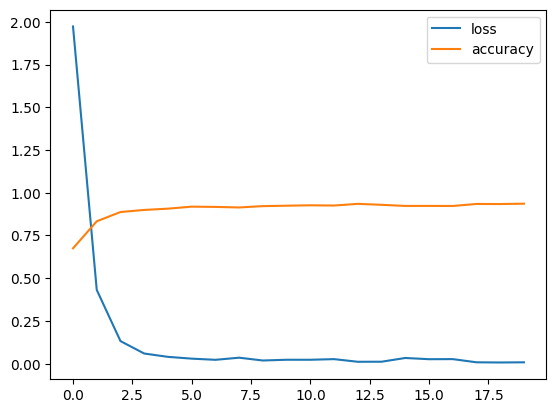

In [22]:
import wandb
run = wandb.init(project='DLA-Lab1', name='resnet18-finetune', config={
        "learning_rate": 0.0001,
        "architecture": "CNN",
        "dataset": "GTSRB",
        "epochs": 20,
    },)

epochs = 20
lr = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

losses = []
accuracies = []
for epoch in tqdm(range(epochs)):
    loss = train_epoch(model, dl_train, optimizer, epoch+1, device=device)
    acc, _ = evaluate_model(model, dl_test, device=device)
    losses.append(loss)
    accuracies.append(acc)
    run.log({"loss": loss, "accuracy": acc})
run.finish()

plt.plot(losses, label='loss')
plt.plot(accuracies, label='accuracy')
plt.legend()

(accuracy, cls_report) = evaluate_model(model, dl_test, device=device)
print(cls_report)


---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

In [23]:
# Your code here.

# Or, even better: Consolidate your code in separate Python modules that you can 
# import here and then REUSE.


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! 

---
### Exercise 3.1 (Easy): Improving Fine-tuning Performance

In this exercise you are asked to iterate on the fine-tuning experiment performed in Exercise 1.3 in order to squeeze the best performance possible out of the model.

What can we do:
- Use a more powerful model?
- More aggressive data augmentation?
- Selective layer training?
- Something else?

**Why choose this exercise?** To hone your skills at incrementally improving fined-tuned model performance via a sequence of (carefully monitored) experiments.

In [24]:
# Your code here.


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.

In [25]:
# Your code here.


---
### Exercise 3.3: *Detecting* Traffic Signs (hardest)

In this exercise you will see if you can take your pretrained *classification* backbone and turn it into a *detector*. We will need another dataset for this -- one with *full image frames* instead of cropped sign images. Luckily, this dataset is available on [Hugging Face](https://huggingface.co/datasets/keremberke/german-traffic-sign-detection) (see below for how to access it).

For this exercise, you could:
1. Start from an available Faster-RCNN model from `torchvision` and *replace* the feature extraction backbone with your ResNet fine-tuned on GTRSB.
2. This *stitched-together* network should do an OK-ish job already of detecting at least *some* traffic signs. See how it performs on some of the images from the GTRSB Detection dataset. Implement a simple function to visualize detections superimposed over the original image. Compute some detection metrics (accuracy @ IoU=0.5, for example).
3. If you're feeling ambitious, you could also *fine-tune* the resulting model to improve detection performance.

**NOTE**: The pretrained Faster-RCNN models in `torchvision` are all based on ResNet-50, so this exercise will likely be much less painful if you use a ResNet-50 from the very start.

**Also Note**: To use the **GTRSB Detection Dataset** you should use the `datasets` package from Hugging Face (version 3.X):

     # If using uv.
     uv add datasets==3

or

     # If using Anaconda
     conda install -c conda-forge datasets==3

In [26]:
from datasets import load_dataset

# Download the full detection dataset from the Hugging Face Hub.
# You will want to spend some time studying the organization of this dataset.
ds = load_dataset("keremberke/german-traffic-sign-detection", name="full")

# Your code here.

ModuleNotFoundError: No module named 'datasets'

---
---